In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os, time

# C-optimized

In [ ]:
dir_data = 'data/N10_K1_S1'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q2 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q2_T = cp.einsum('...ac,...bc->...abc', history, history) # taking outer product of spins across sites in a sample
    q2_T = q2_T.reshape(*q2_T.shape[:3], q2_T.shape[3]**2, 3) # flattening outer product
    q2_T = cp.mean(q2_T, axis=0) # taking time average (thermal ave. if ergodic)
    q2_T = cp.mean(q2_T**2, axis=(0,1,2)) # taking site average of squares across (disorder, replica, site)
    q2.append(q2_T)
    print(f'\rq2 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%     ', end='')
q2 = cp.array(q2).get()
cp.save(f'{dir_data}/q2.npy', q2) # saving q2
print('Done.')

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q2_T = cp.einsum('...ac,...bc->...abc', history, history) # taking outer product of spins across sites in a sample
    q2_T = q2_T.reshape(*q2_T.shape[:3], q2_T.shape[3]**2, 3) # flattening outer product
    q4_T_list = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            out = q2_T[:,j,k,:,:] # working with one sample
            out = cp.einsum('...ac,...bc->...abc', out, out) # taking outer product of spin-pairs in a sample (out: quadruple product)
            out = out.reshape(out.shape[0], out.shape[1]**2, out.shape[-1]) # flattening outer product matrix
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = cp.mean(out**2, axis=0) # taking permutation average of squared quadruple products
            q4_T_list.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {100*subprogress/history.shape[1]/history.shape[2]}%     ', end='')
    q4_T = cp.mean(cp.array(q4_T_list), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('Done.')

q2 Progress: 100.0%     Done.
q4 Progress: 100.0%; Subprogress: 100.0%     Done.


In [46]:
Uq = (3 - q4/q2**2)/2
np.save(f'{dir_data}/Uq.npy', Uq)

Text(0.5, 1.0, 'N=10')

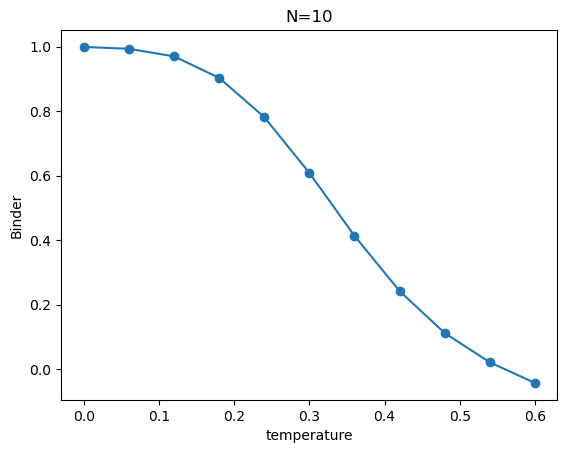

In [ ]:
plt.plot(T_vals, Uq[:,2], marker='o')
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.title('N=10')